In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [ ]:
def radial_mask(r, cx=128, cy=128, sx=np.arange(0, 256), sy=np.arange(0, 256), delta=1):
    ind = (sx[np.newaxis, :] - cx) ** 2 + (sy[:, np.newaxis] - cy) ** 2
    ind1 = ind <= ((r[0] + delta) ** 2)  # one liner for this and below?
    ind2 = ind > (r[0] ** 2)
    return ind1 * ind2

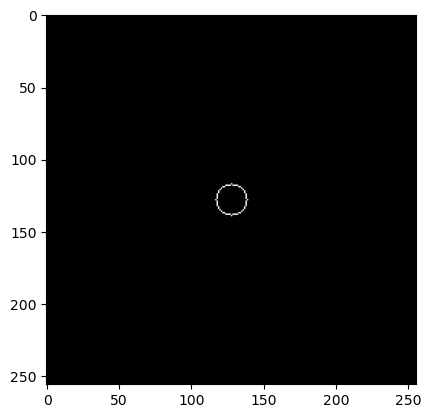

In [ ]:
# Usage example
r = np.array([10])  # Ring radius
mask = radial_mask(r, cx= 128)

# Show radial mask
plt.imshow(mask, cmap='gray')
plt.show()

In [ ]:
def get_radial_masks(width, height):
    freq_nyq = int(np.floor(int(min(width, height)) / 2.0))
   
    
    radii = np.arange(freq_nyq).reshape(freq_nyq, 1) 
    
    radial_masks = np.apply_along_axis(radial_mask, 1, radii, width/2, height/2, np.arange(0, width), np.arange(0, height), 1)
    radial_masks = np.expand_dims(radial_masks, 1)
    radial_masks = np.expand_dims(radial_masks, 1)

    spatial_freq = radii.astype(np.float32) / freq_nyq
    spatial_freq = spatial_freq / max(spatial_freq)

    return radial_masks, spatial_freq

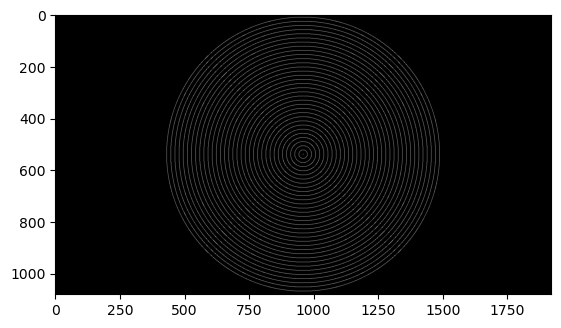

In [ ]:
#Show radial masks

radial_masks, _ = get_radial_masks(1920,1080)

radial_masks = radial_masks.squeeze((1,2))

combined_image = np.zeros(radial_masks.shape[1:])  # Crear una matriz de ceros con las mismas dimensiones que las imágenes

# Plot not all the radial masks for visual convinience
for i in range(0, radial_masks.shape[0], 16):
    array_2d = radial_masks[i, :, :]
    combined_image += array_2d  # Sum of every ring

# Plot radial masks
plt.imshow(combined_image, cmap='gray')
plt.show()

In [ ]:
def get_fourier_ring_correlations(image1, image2):

    # Get image height and width

    height = image1.shape[len(image1.shape)-1]
    

    width = image1.shape[len(image1.shape)-2]
    
    # Get set of radial masks, spatial frecuency and nyquist frequency
    
    radial_masks, spatial_frequency = get_radial_masks(height,width)

    freq_nyq = len(spatial_frequency)
    
    # Transform tensor to complex
    image1 = image1.to(torch.complex64)
    image2 = image2.to(torch.complex64)
    
    image1 = image1.unsqueeze(0).repeat(freq_nyq, 1, 1)
    image2 = image2.unsqueeze(0).repeat(freq_nyq, 1, 1)
    
    radial_masks = radial_masks.squeeze((1,2))


    spatial_frequency = torch.from_numpy(spatial_frequency.squeeze(1))

    radial_masks = torch.from_numpy(radial_masks)
    
    radial_masks = radial_masks.to(torch.complex64)
         
    # Compute fourier transform
    fft_image1 = torch.fft.fftshift(torch.fft.fft2(image1))
    fft_image2 = torch.fft.fftshift(torch.fft.fft2(image2))

    # Get elements only in the ring
    t1 = fft_image1 * radial_masks
    t2 = fft_image2 * radial_masks
        
    # image2 to complex conjugate
    t2_conj = t2.conj()

    # Numerator
    numerador = torch.abs(torch.real((t1 * t2_conj).sum(dim=(1,2))))

    # Denominator    
    denominador_1 = ((torch.abs(t1) * torch.abs(t1)).sum(dim=(1,2)))
    denominador_2 = ((torch.abs(t2) * torch.abs(t2)).sum(dim=(1,2)))     
    denominador = torch.sqrt(denominador_1 * denominador_2)
   
    # Fourier shell correlation
    FRC = torch.div(numerador, denominador)

    # Remove possible inf and NaN.
    FRC = torch.where(torch.isinf(FRC), torch.zeros_like(FRC), FRC)  # inf
    FRC = torch.where(torch.isnan(FRC), torch.zeros_like(FRC), FRC)  # NaN

    return FRC , spatial_frequency

In [ ]:
def FRCM(image1, image2):

    FRC, spatial_frequency = get_fourier_ring_correlations(image1, image2)

    FRC = FRC.numpy()
    spatial_frequency = spatial_frequency.numpy()
      

    area = np.trapz(FRC, spatial_frequency)
    
    return area

In [ ]:
def FRCLoss(image1, image2):

    
    return (1 - FRCM(image1, image2))

In [ ]:
image1 = torch.randn(225, 225)
image2 = torch.randn(225, 225)


print(FRCM(image1, image2))
FRCLoss(image1, image2)

0.04795546


0.9520445391535759

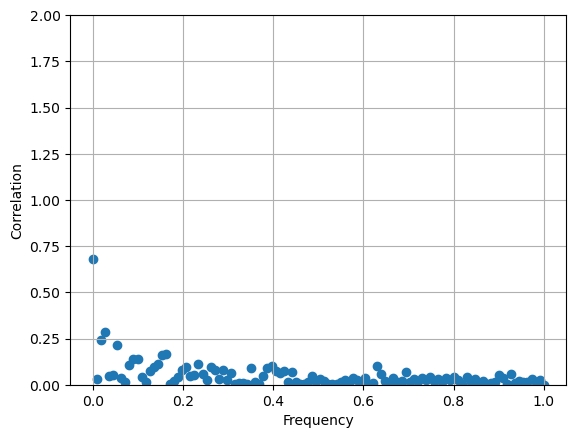

In [ ]:
FSC, spatial_frequency = get_fourier_ring_correlations(image1, image2)


x = spatial_frequency.numpy()
y = FSC.numpy()



# Plot scatter graph
plt.scatter(x, y)

plt.xlabel('Frequency')
plt.ylabel('Correlation')
plt.ylim(0, 100)
plt.grid(True)
plt.ylim(0, 2);

In [ ]:
from scipy.optimize import curve_fit


def seventh_fourier_ring_correlation(image1,image2):

    y, x = get_fourier_ring_correlations(image1, image2)

    x = x.numpy()
    y = y.numpy()


    # Definir la función exponencial
    def exponential_func(x, a, b, c):
        return a * np.exp(-b * x) + c

    # Realizar el ajuste
    params, params_covariance = curve_fit(exponential_func, x, y, p0=[1, 1, 1])

    # Generar datos para la curva ajustada
    x_fit = np.linspace(0, 1, 100)
    y_fit = exponential_func(x_fit, *params)
   

    cutoff_frequency = (exponential_func((1/7), *params))

    return cutoff_frequency

Imagen 1: (225, 225), uint8
Imagen 2: (225, 225), uint8
0.8775546178221703


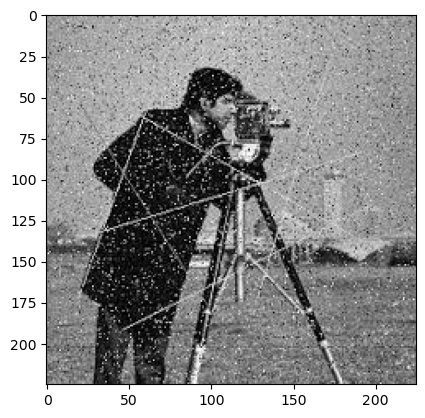

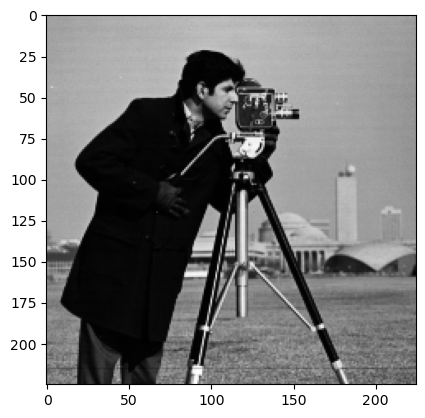

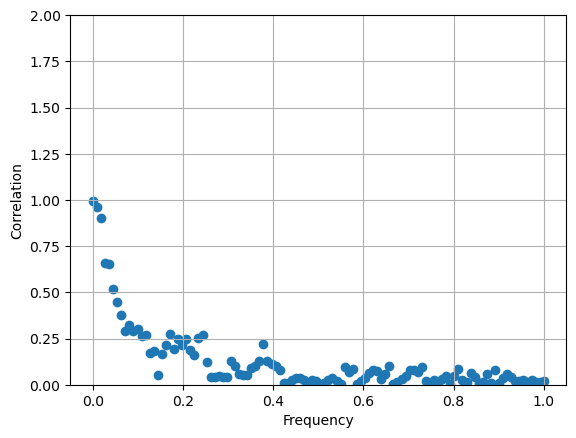

0.1939677427309104


In [ ]:
#Try example with images

from PIL import Image
import numpy as np

# Load images
image1 = Image.open('data_examples/cameraman_noisy.jpg')
image2 = Image.open('data_examples/cameraman_clean.png')

# Convert images to numpy array
array1 = np.array(image1)
array1 = array1[:, :, 0]
array2 = np.array(image2)

#Crop second image
start_x = (array2.shape[1] - 225) // 2  
start_y = (array2.shape[0] - 225) // 2  

end_x = start_x + 225
end_y = start_y + 225


array2 = array2[start_y:end_y, start_x:end_x]

# Show images dimensions
print(f"Imagen 1: {array1.shape}, {array1.dtype}")
print(f"Imagen 2: {array2.shape}, {array2.dtype}")

# Convert to torch tensors
tensor1 = torch.from_numpy(array1)
tensor2 = torch.from_numpy(array2)


print(FRCLoss(tensor1, tensor2))

# Plot iamge1
plt.imshow(array1, cmap='gray')
plt.show()


# Plot image2
plt.imshow(array2, cmap='gray')
plt.show()

y, x = get_fourier_ring_correlations(tensor1, tensor2)


# Plot scatter graph
plt.scatter(x, y)
plt.xlabel('Frequency')
plt.ylabel('Correlation')
plt.ylim(0, 100)
plt.grid(True);
plt.ylim(0, 2);
plt.show()


# Cutoff frequency
print(seventh_fourier_ring_correlation(tensor1,tensor2))